# Dates visualisation

Imagery year by reporting unit

In [1]:
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('src').resolve()))
def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)
sys.path.insert(0, str(_find_root(Path.cwd())))
import paths

pd.set_option('display.max_rows', 120)
BASE = Path('.').resolve()
print("Dossier de travail :", BASE)
# the source of each file (see FIG_PREFIX)
FIGS_DIR = paths.FIGURES

Dossier de travail : /sessions/happy-gracious-franklin/mnt/Publication/source/code/0_pipeline/postprocess/dates


In [2]:
recal=gpd.read_file(paths.IMAGERY_DATES)

departements_gdf = gpd.read_file(
    paths.DEPARTEMENTS
)

if departements_gdf.crs is None:
    departements_gdf = departements_gdf.set_crs("EPSG:4326")
else:
    departements_gdf = departements_gdf.to_crs("EPSG:4326")

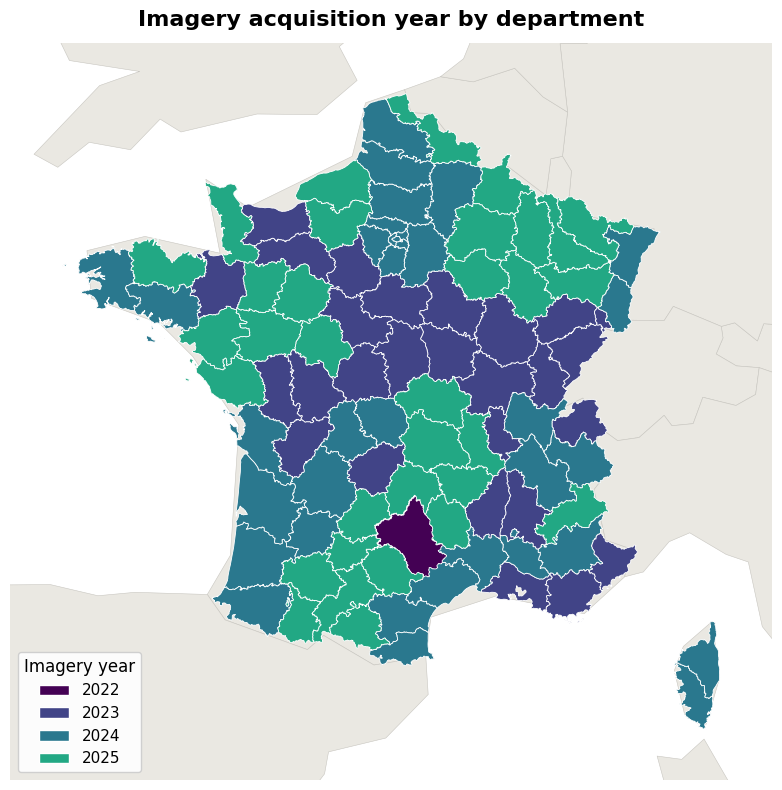

In [3]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ================================================================
# Configuration
# ================================================================

WORLD_LOWRES_FILE = Path(
    paths.WORLD
)

world = gpd.read_file(WORLD_LOWRES_FILE)


# Basemap colors
BASEMAP_LAND = "#EAE8E2"
BASEMAP_SEA = "#FFFFFF"
BASEMAP_EDGE = "#C8C6C0"


# ================================================================
# Basemap
# ================================================================

def add_basemap(
    ax,
    bounds,
    margin=0.08,
):
    """Static Natural Earth 1:110m basemap."""

    ax.set_facecolor(BASEMAP_SEA)

    world.plot(
        ax=ax,
        color=BASEMAP_LAND,
        edgecolor=BASEMAP_EDGE,
        linewidth=0.4,
        zorder=0,
    )

    xmin, ymin, xmax, ymax = bounds

    dx = (xmax - xmin) * margin
    dy = (ymax - ymin) * margin

    ax.set_xlim(
        xmin - dx,
        xmax + dx,
    )

    ax.set_ylim(
        ymin - dy,
        ymax + dy,
    )


def hide_axis_chrome(ax):
    """Remove axes while preserving the basemap."""

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


# ================================================================
# Prepare commune-level data
# ================================================================

recal_map = recal.copy()

# Normalize department codes
recal_map["dpt"] = recal_map["dpt"].astype(str).apply(
    lambda x: x if x in ["2A", "2B"] else x.zfill(2)
)

# Remove communes without imagery date
recal_map = recal_map.dropna(
    subset=["year_median"]
).copy()

# Make sure year is numeric
recal_map["year_median"] = (
    recal_map["year_median"]
    .astype(float)
)


# ================================================================
# Aggregate to department level
# ================================================================

dpt_year = (
    recal_map
    .groupby("dpt")["year_median"]
    .median()
    .reset_index()
)

# Integer years for clean legend labels
dpt_year["year_median"] = (
    dpt_year["year_median"]
    .round()
    .astype(int)
)


# ================================================================
# Join with department geometries
# ================================================================

departements_map = departements_gdf.copy()

departements_map["code"] = (
    departements_map["code"]
    .astype(str)
    .apply(
        lambda x: x if x in ["2A", "2B"] else x.zfill(2)
    )
)

departements_map = departements_map.merge(
    dpt_year,
    left_on="code",
    right_on="dpt",
    how="left",
)


# ================================================================
# Define one color per year
# ================================================================

years = sorted(
    departements_map["year_median"]
    .dropna()
    .unique()
)

# Discrete palette
year_colors = [
    "#440154",
    "#414487",
    "#2A788E",
    "#22A884",
    "#7AD151",
    "#FDE725",
    "#F8961E",
    "#D73027",
]

if len(years) > len(year_colors):
    raise ValueError(
        f"{len(years)} distinct years found, "
        f"but only {len(year_colors)} colors are defined."
    )

year_to_color = dict(
    zip(years, year_colors)
)


# ================================================================
# Plot
# ================================================================

bounds = departements_map.total_bounds

fig, ax = plt.subplots(
    figsize=(12, 8),
)

add_basemap(
    ax,
    bounds,
    margin=0.08,
)


# Plot departments by year
for year in years:

    subset = departements_map[
        departements_map["year_median"] == year
    ]

    subset.plot(
        ax=ax,
        color=year_to_color[year],
        edgecolor="white",
        linewidth=0.6,
        zorder=1,
    )


# Departments without imagery information
missing = departements_map[
    departements_map["year_median"].isna()
]

if not missing.empty:

    missing.plot(
        ax=ax,
        color="#D9D9D9",
        edgecolor="white",
        linewidth=0.6,
        zorder=1,
    )


# ================================================================
# Legend
# ================================================================

legend_handles = [
    Patch(
        facecolor=year_to_color[year],
        edgecolor="white",
        label=str(year),
    )
    for year in years
]

if not missing.empty:
    legend_handles.append(
        Patch(
            facecolor="#D9D9D9",
            edgecolor="white",
            label="No data",
        )
    )


ax.legend(
    handles=legend_handles,
    title="Imagery year",
    loc="lower left",
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    framealpha=0.9,
)


# ================================================================
# Title
# ================================================================

ax.set_title(
    "Imagery acquisition year by department",
    fontsize=16,
    fontweight="bold",
    pad=12,
)

hide_axis_chrome(ax)

plt.tight_layout()

plt.savefig(
    paths.FIGURES / 'department_imagery_year.pdf',
    bbox_inches="tight",
)

plt.show()